In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/FuelConsumptionCo2.csv')
data.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [ ]:
data.isnull().sum()

,0
MODELYEAR,0
MAKE,0
MODEL,0
VEHICLECLASS,0
ENGINESIZE,0
CYLINDERS,0
TRANSMISSION,0
FUELTYPE,0
FUELCONSUMPTION_CITY,0
FUELCONSUMPTION_HWY,0


In [ ]:
X = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB']]
y = data['CO2EMISSIONS']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

In [ ]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1/(2*m)) * np.sum((predictions - y) ** 2)
    return cost

def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y
        gradient = (1/m) * X.T.dot(error)
        theta -= alpha * gradient
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

In [ ]:
initial_theta = np.zeros(X_train.shape[1])
alpha = 0.01
iterations = 1000

In [ ]:
theta_optimal, cost_history = gradient_descent(X_train, y_train, initial_theta, alpha, iterations)
print("Optimized theta:", theta_optimal)

Optimized theta: [256.57571701  15.04513618  13.79996249  12.47460736   9.30858627
  11.49118329]


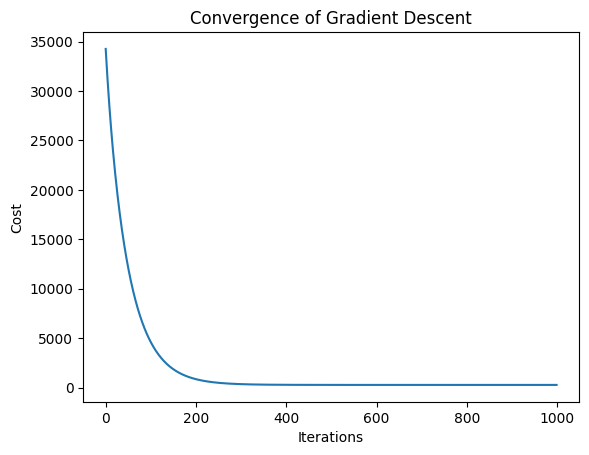

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Convergence of Gradient Descent')
plt.show()

In [ ]:
predictions = X_test.dot(theta_optimal)


In [ ]:
mse = np.mean((predictions - y_test) ** 2)
print(f"Mean Squared Error (MSE) on Test Set: {mse}")

Mean Squared Error (MSE) on Test Set: 514.4206103907422


In [ ]:
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)
ss_residual = np.sum((y_test - predictions) ** 2)
r_squared = 1 - (ss_residual / ss_total)
print(f"R-squared value: {r_squared}")


R-squared value: 0.875591924800146


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Set up figure size for plots
plt.rcParams['figure.figsize'] = (12.0, 9.0)

# Step 1: Load the dataset
data = pd.read_csv('/content/FuelConsumptionCo2.csv')

In [ ]:
X = data[['ENGINESIZE', 'CYLINDERS', 'FUELCONSUMPTION_CITY', 'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB']].values
Y = data['CO2EMISSIONS'].values

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = np.c_[np.ones(X_scaled.shape[0]), X_scaled]

In [ ]:
theta = np.zeros(X_scaled.shape[1])
L = 0.0001  # Learning rate
epochs = 1000
n = float(len(X_scaled))

In [ ]:
for i in range(epochs):
    Y_pred = np.dot(X_scaled, theta)
    error = Y_pred - Y

    # Calculate the gradient (derivative of the cost function with respect to theta)
    gradients = (1/n) * np.dot(X_scaled.T, error)

    # Update the parameters using the gradient and learning rate
    theta -= L * gradients

    # Optionally print the values of theta for each iteration
    if i % 100 == 0:  # Print every 100 iterations
        print(f"Iteration {i + 1}: theta = {theta}")

Iteration 1: theta = [0.02562287 0.00553712 0.00538212 0.00568841 0.00545854 0.00565097]
Iteration 101: theta = [2.5750127  0.54721541 0.53193402 0.56184876 0.53900282 0.55810123]
Iteration 201: theta = [5.09903442 1.06576036 1.03607005 1.09363452 1.04888672 1.08624128]
Iteration 301: theta = [7.59794045 1.56217671 1.51876326 1.60210746 1.5361416  1.59113031]
Iteration 401: theta = [10.07198072  2.03742549  1.98094439  2.08828313  2.00175388  2.07378145]
Iteration 501: theta = [12.52140265  2.4924259   2.42350368  2.55313287  2.44666709  2.5351637 ]
Iteration 601: theta = [14.94645121  2.92805717  2.84729263  2.99758576  2.87178367  2.9762039 ]
Iteration 701: theta = [17.34736893  3.34516027  3.25312572  3.42253045  3.27796679  3.39778854]
Iteration 801: theta = [19.72439594  3.74453959  3.64178198  3.8288169   3.66604206  3.80076555]
Iteration 901: theta = [22.07776995  4.1269645   4.01400655  4.21725808  4.03679912  4.18594594]
